In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/CMPE 401/Instructor Defined 1/baseline_yolo11n"

Mounted at /content/drive


## **Part II: Loss Curve and Fitting Analysis**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = f"{BASE}/results.csv"

df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()

# final epoch metrics
final = df.iloc[-1]
print("=== Final Epoch Results ===")
print(f"mAP@50:        {final['metrics/mAP50(B)']:.4f}")
print(f"mAP@50-95:     {final['metrics/mAP50-95(B)']:.4f}")
print(f"Precision:     {final['metrics/precision(B)']:.4f}")
print(f"Recall:        {final['metrics/recall(B)']:.4f}")
print(f"Train Box Loss:{final['train/box_loss']:.4f}")
print(f"Val Box Loss:  {final['val/box_loss']:.4f}")

=== Final Epoch Results ===
mAP@50:        0.3494
mAP@50-95:     0.2014
Precision:     0.4472
Recall:        0.3467
Train Box Loss:1.3864
Val Box Loss:  1.4111


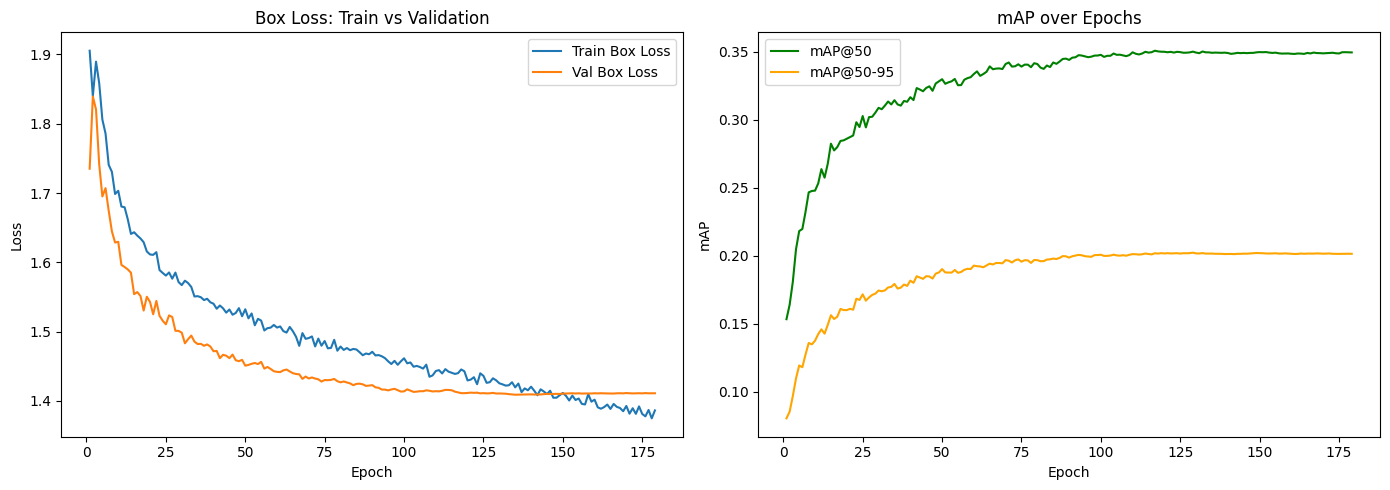

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
axes[0].set_title('Box Loss: Train vs Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# mAP curve
axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green')
axes[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='orange')
axes[1].set_title('mAP over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{BASE}/loss_map_curves.png", dpi=150)
plt.show()

In [ ]:
summary = {
    "Model": ["YOLOv11n"],
    "Epochs": [len(df)],
    "mAP@50": [round(final['metrics/mAP50(B)'], 4)],
    "mAP@50-95": [round(final['metrics/mAP50-95(B)'], 4)],
    "Precision": [round(final['metrics/precision(B)'], 4)],
    "Recall": [round(final['metrics/recall(B)'], 4)],
}
pd.DataFrame(summary)

,Model,Epochs,mAP@50,mAP@50-95,Precision,Recall
0,YOLOv11n,179,0.3494,0.2014,0.4472,0.3466


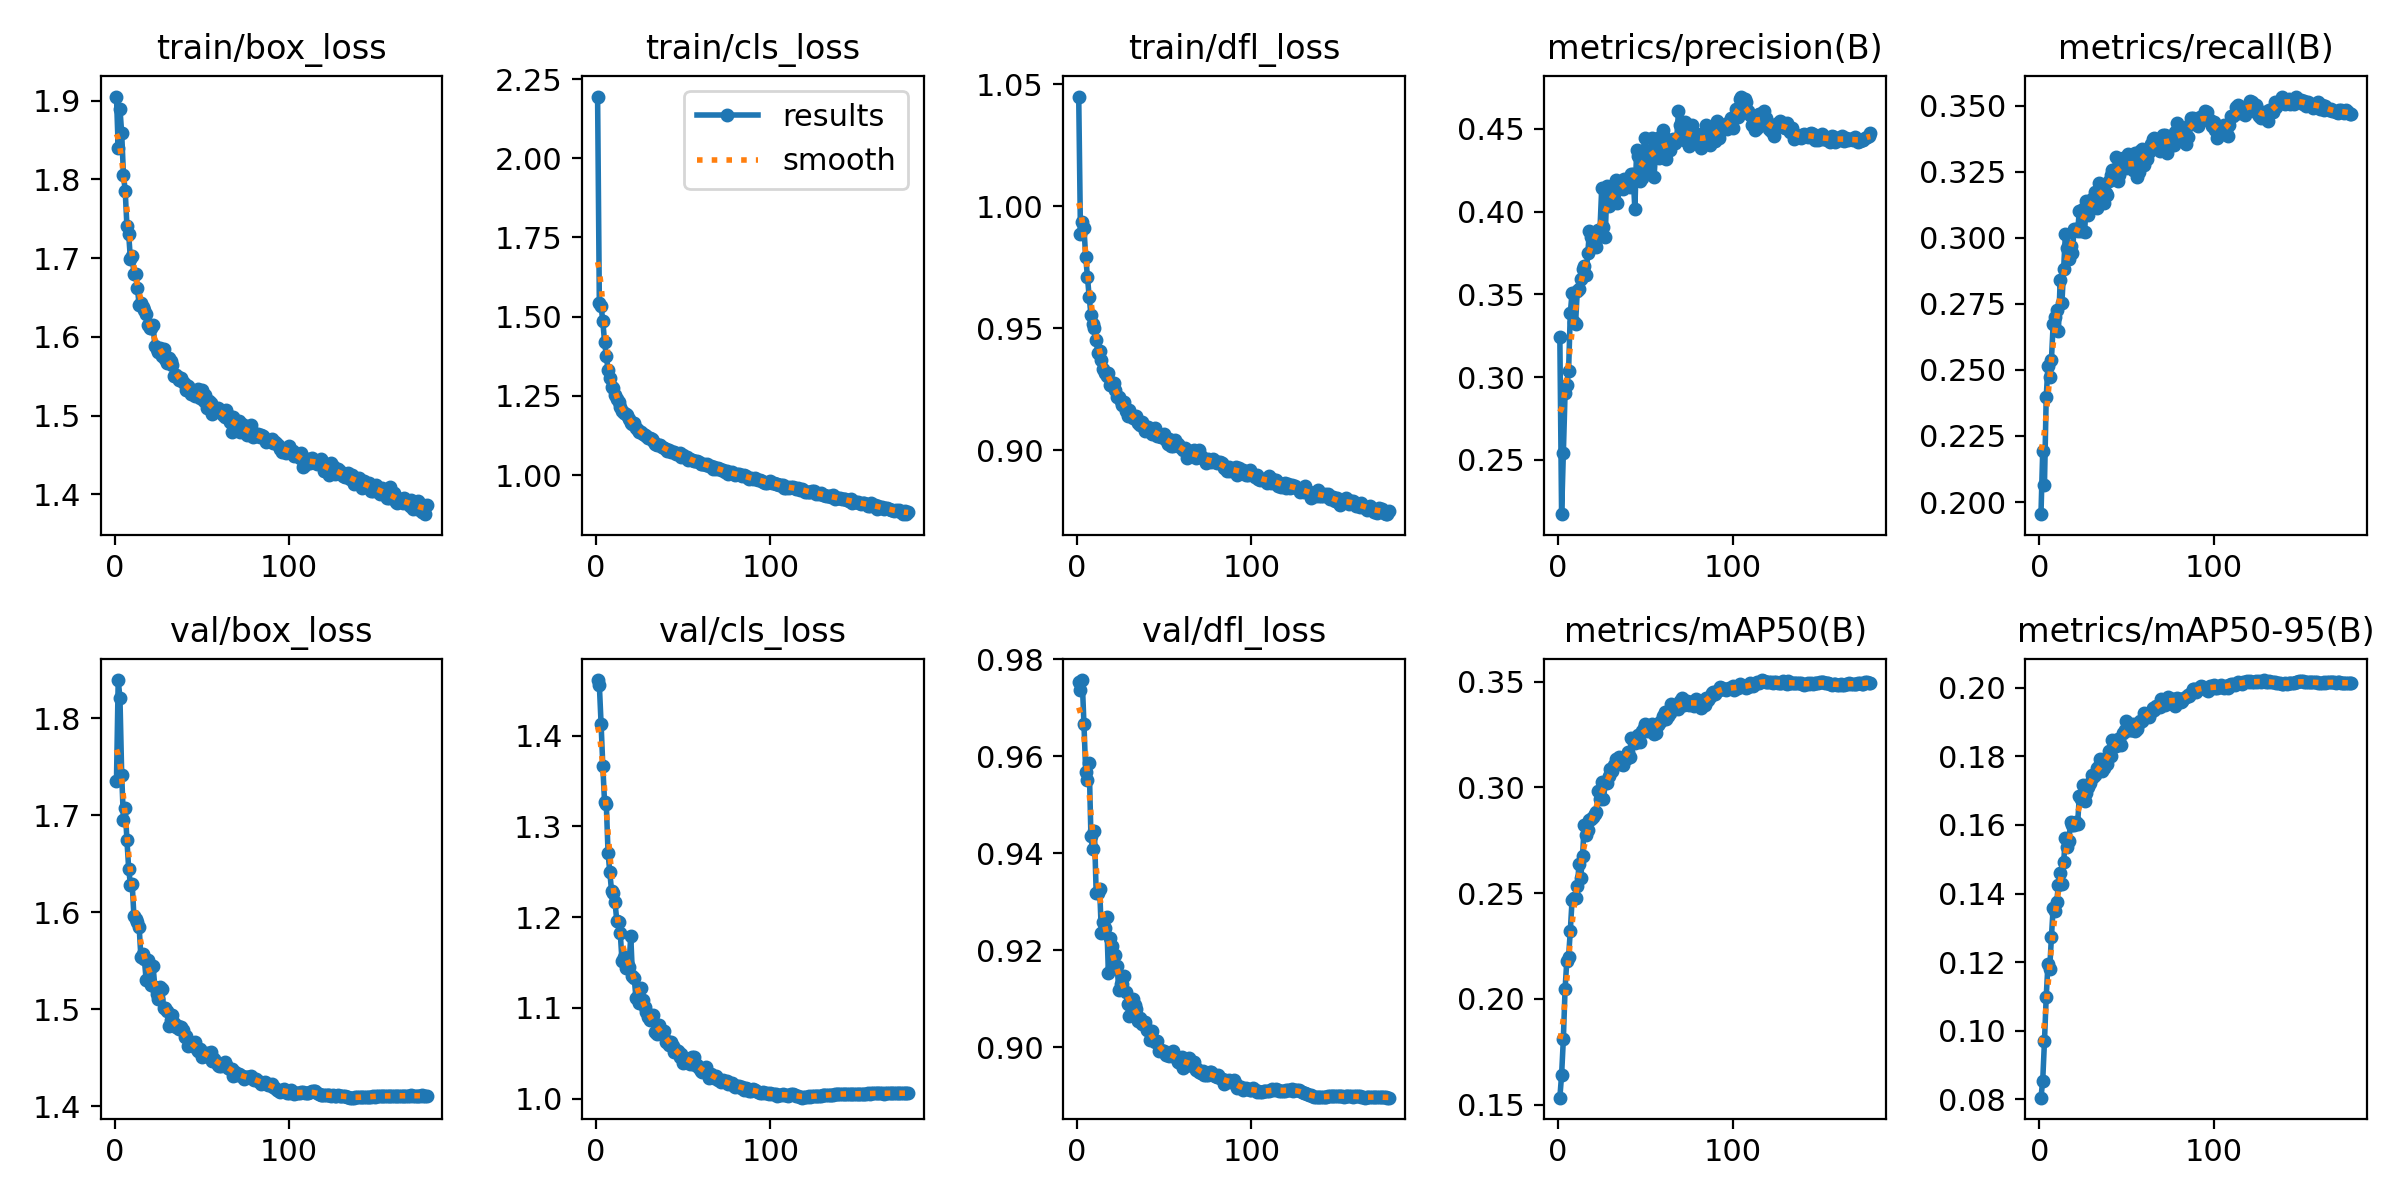

In [ ]:
from IPython.display import Image, display
display(Image(f"{BASE}/results.png"))

### **Discussion**
**Note:** 200 epochs were set with a patience of 50 during training. Training stopped at 179 epochs since there was no improvement in the last 50 epochs (129 epochs).

### 1. Training vs. Validation Loss

The loss curves above plot the **box loss** for both the training set and the validation set across all 179 epochs. The key observations are:

- Both curves descend steadily from the start of training, indicating the model is learning meaningful object detection features.
- After approximately epoch 80–100, both curves begin to slow down, with only small decreases in loss through the remaining epochs.
- At the final epoch (epoch 179), the **training box loss is 1.3864** and the **validation box loss is 1.4111**, a gap of roughly **0.025**.

### 2. Convergence Behavior

The model has **converged**. Convergence is visible because:
- Neither the training nor the validation loss shows meaningful improvement in the later epochs.
- The mAP@50 stabilizes around **0.34–0.35** and mAP@50-95 around **0.20**, with no upward trend continuing toward the end of training.
- Both curves are smooth and consistent without sudden spikes, suggesting stable gradient updates and appropriate learning rate scheduling.

It is also worth noting that early stopping with patience=50 was enabled, and training stopped at epoch 129 based on the best checkpoint, with the best model saved as best.pt.
This confirms the model had genuinely converged and additional epochs would not have improved performance.

### 3. Results Curves (results.png)

The results.png panel shows all training and validation losses alongside precision, recall, mAP@50, and mAP@50-95 across all epochs.

All three training losses (box, cls, dfl) decrease consistently throughout training without divergence, indicating stable optimization.
The validation losses mirror this behavior but plateau slightly earlier, which is a normal and healthy pattern.

Precision is noticeably noisy throughout training, fluctuating across epochs.
This is common in YOLO training because precision is threshold-sensitive, meaning small shifts in the confidence threshold during validation can cause visible swings in the metric.
The smoothed trend shows precision stabilizing around **0.44–0.45**, consistent with the final reported value of 0.4472.

Recall shows a steadier upward trend, gradually improving across training and settling around **0.34–0.35**.
Both mAP curves rise in the first half of training and then plateau, confirming convergence.
The gap between mAP@50 (0.3494) and mAP@50-95 (0.2014) reflects that the model finds objects in roughly the right location but struggles with tight bounding box localization, which is expected for a nano model.

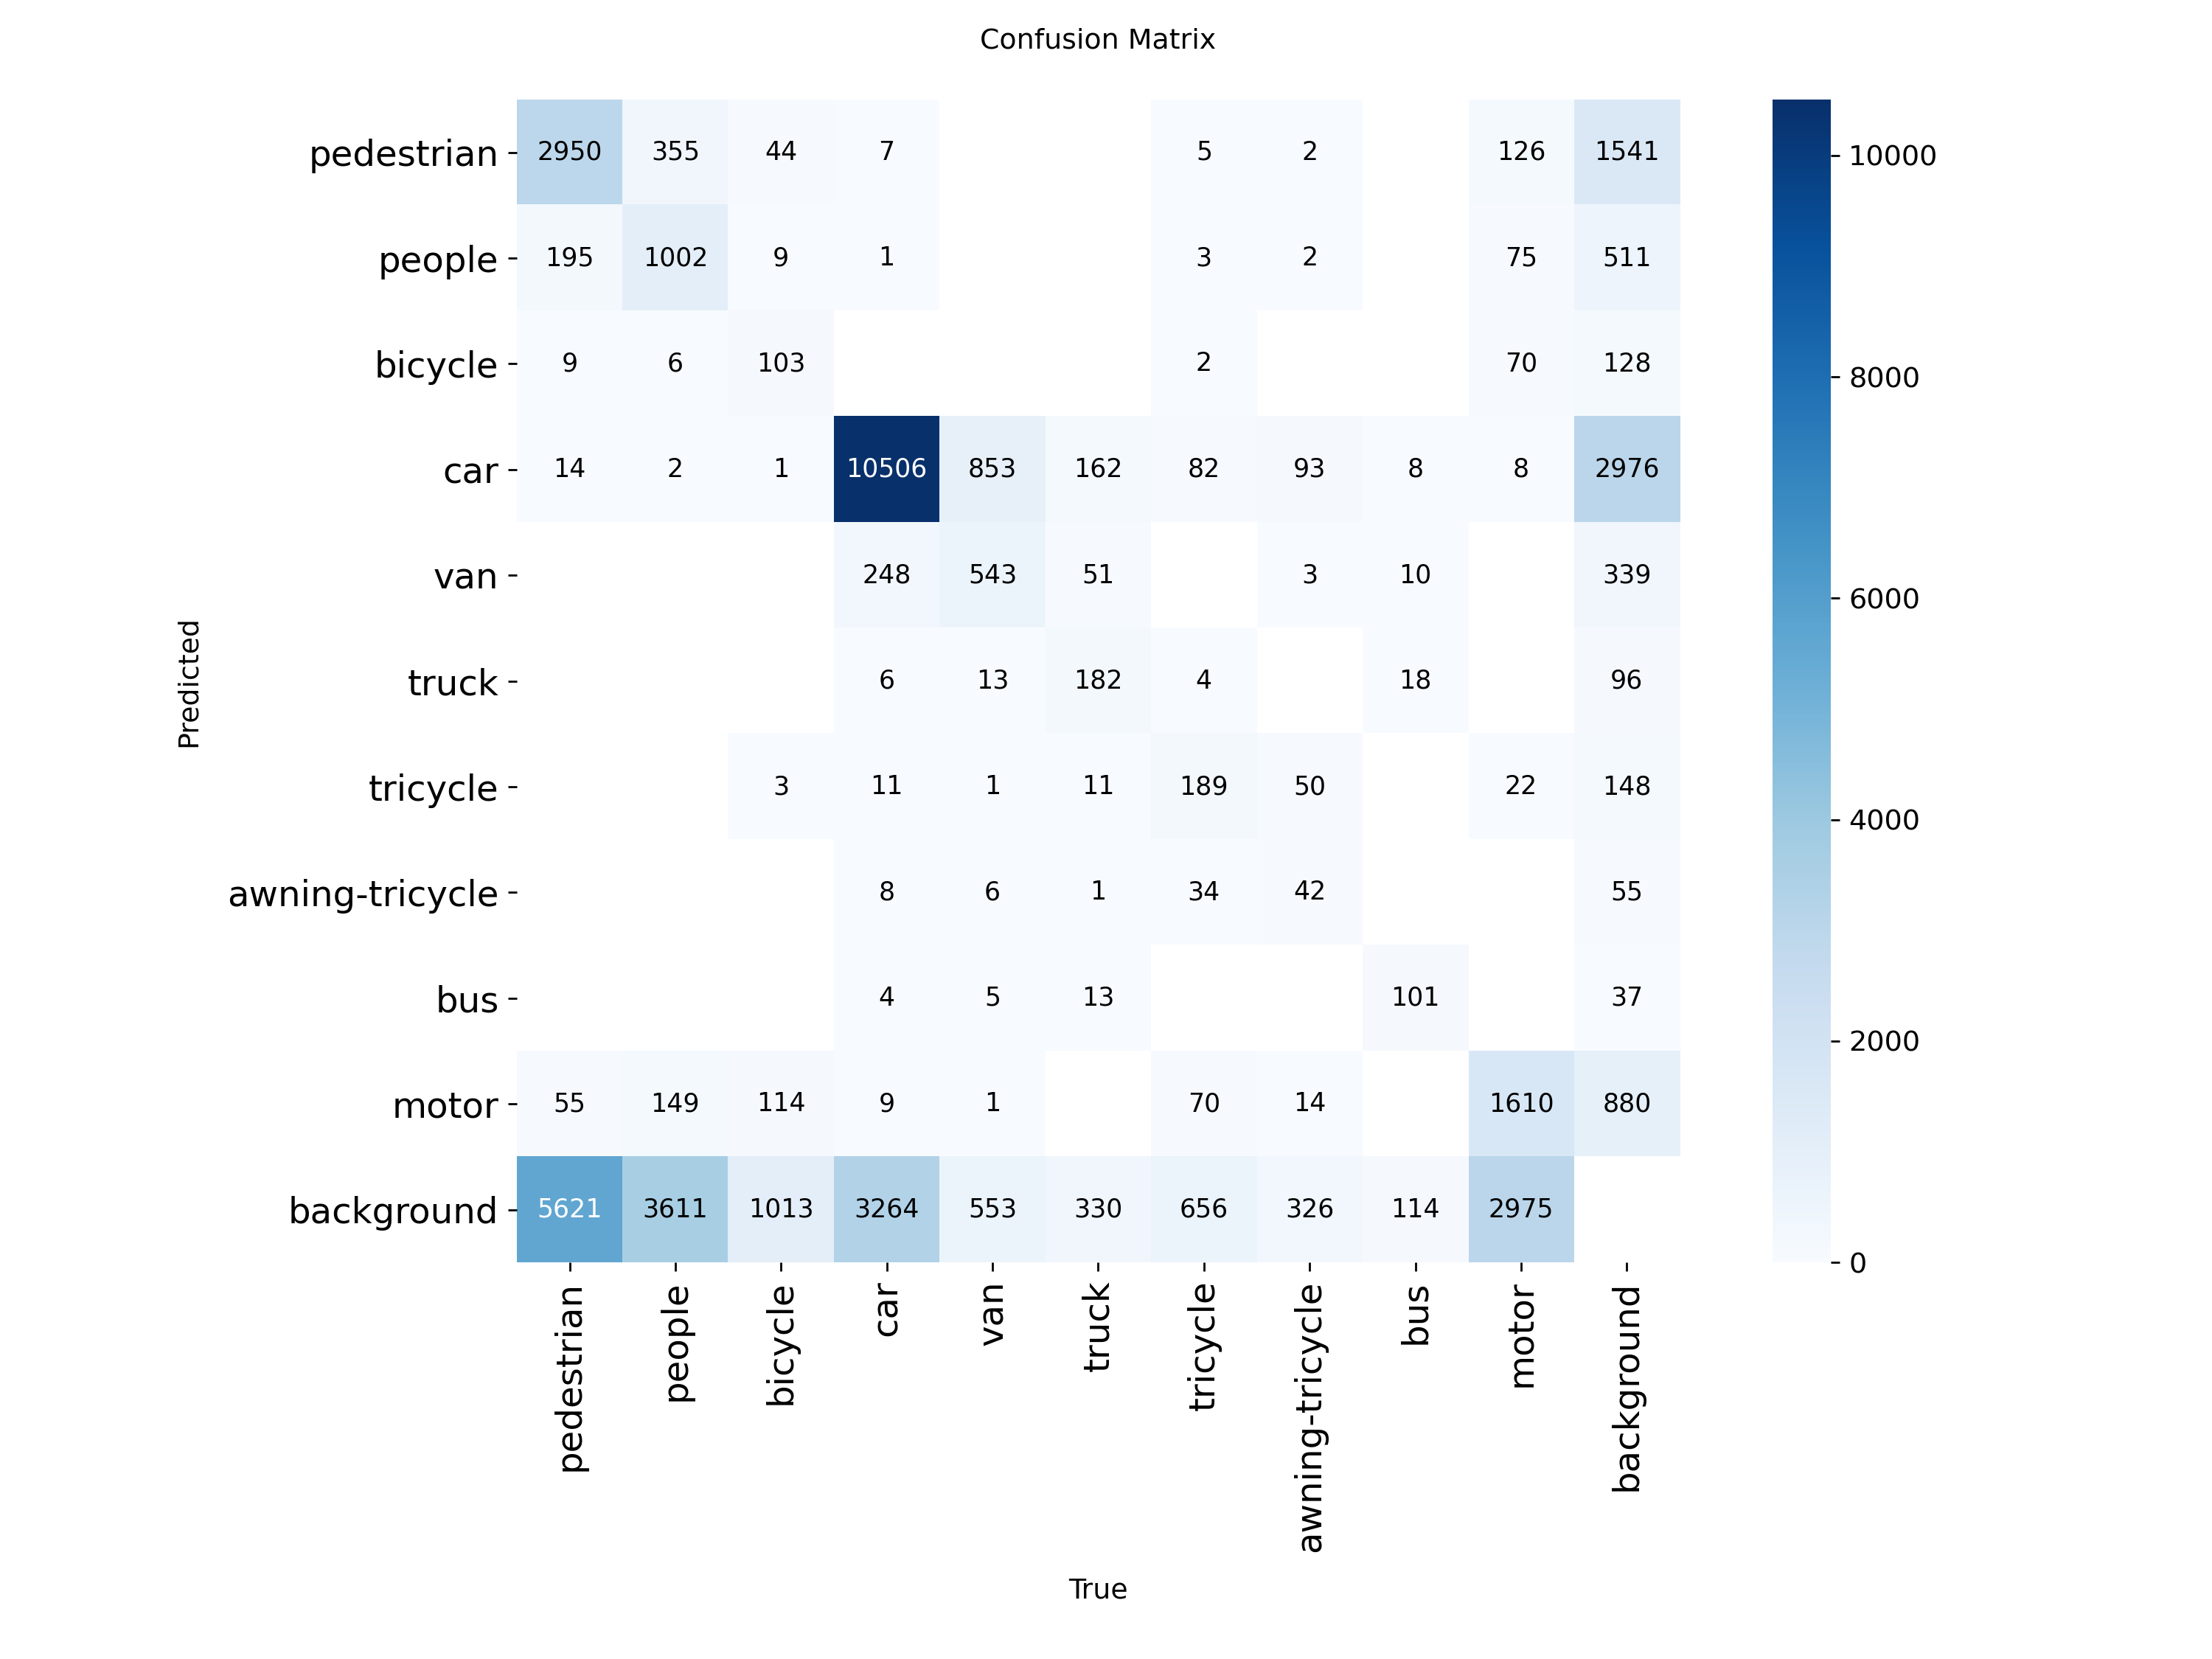

In [ ]:
display(Image(f"{BASE}/confusion_matrix.png"))

### **Discussion**

### 4. Confusion Matrix

The confusion matrix shows detections across **all 10 classes**.
This confirms that the dataset used for is properly balanced with sufficient representation across all classes.

**Car:**
Car is the strongest performing class, which aligns with it having the highest number of instances (14,064) in the validation set.
The model confidently detects cars with relatively few misclassifications, contributing the most to the overall mAP.

**Pedestrian and People:**
Both pedestrian and people show reasonable detections but also notable background confusion.
Cross-class confusion between pedestrian and people is expected since both describe human figures and are visually similar, especially at the small scales typical of drone imagery.
Some instances of each class are suppressed as background, which contributes to the lower overall recall of 0.3467.

**Bicycle, Tricycle, and Awning-Tricycle:**
These classes show weaker detection performance.
They are smaller, less frequent objects that are harder to distinguish at low resolution, and their lower instance counts in the dataset mean the model has seen fewer examples to learn from.
This is reflected in their lower per-class average precision values in the Precision-Recall curve.

**Bus and Van:**
Bus and van show some detection performance.
Van is sometimes confused with car or truck due to visual similarity in shape and size, which is a common challenge in vehicle detection tasks.

**Overall:**
The biggest issue shown in the confusion matrix is that the model misses a lot of objects across most classes, incorrectly labeling them as background. There is high rate of **false negatives**. This is why recall (0.3467) is lower than precision (0.4472). When the model does make a detection it tends to be correct, but it fails to detect a large portion of the objects that are actually there. Improving recall would be the most impactful next step for this model.

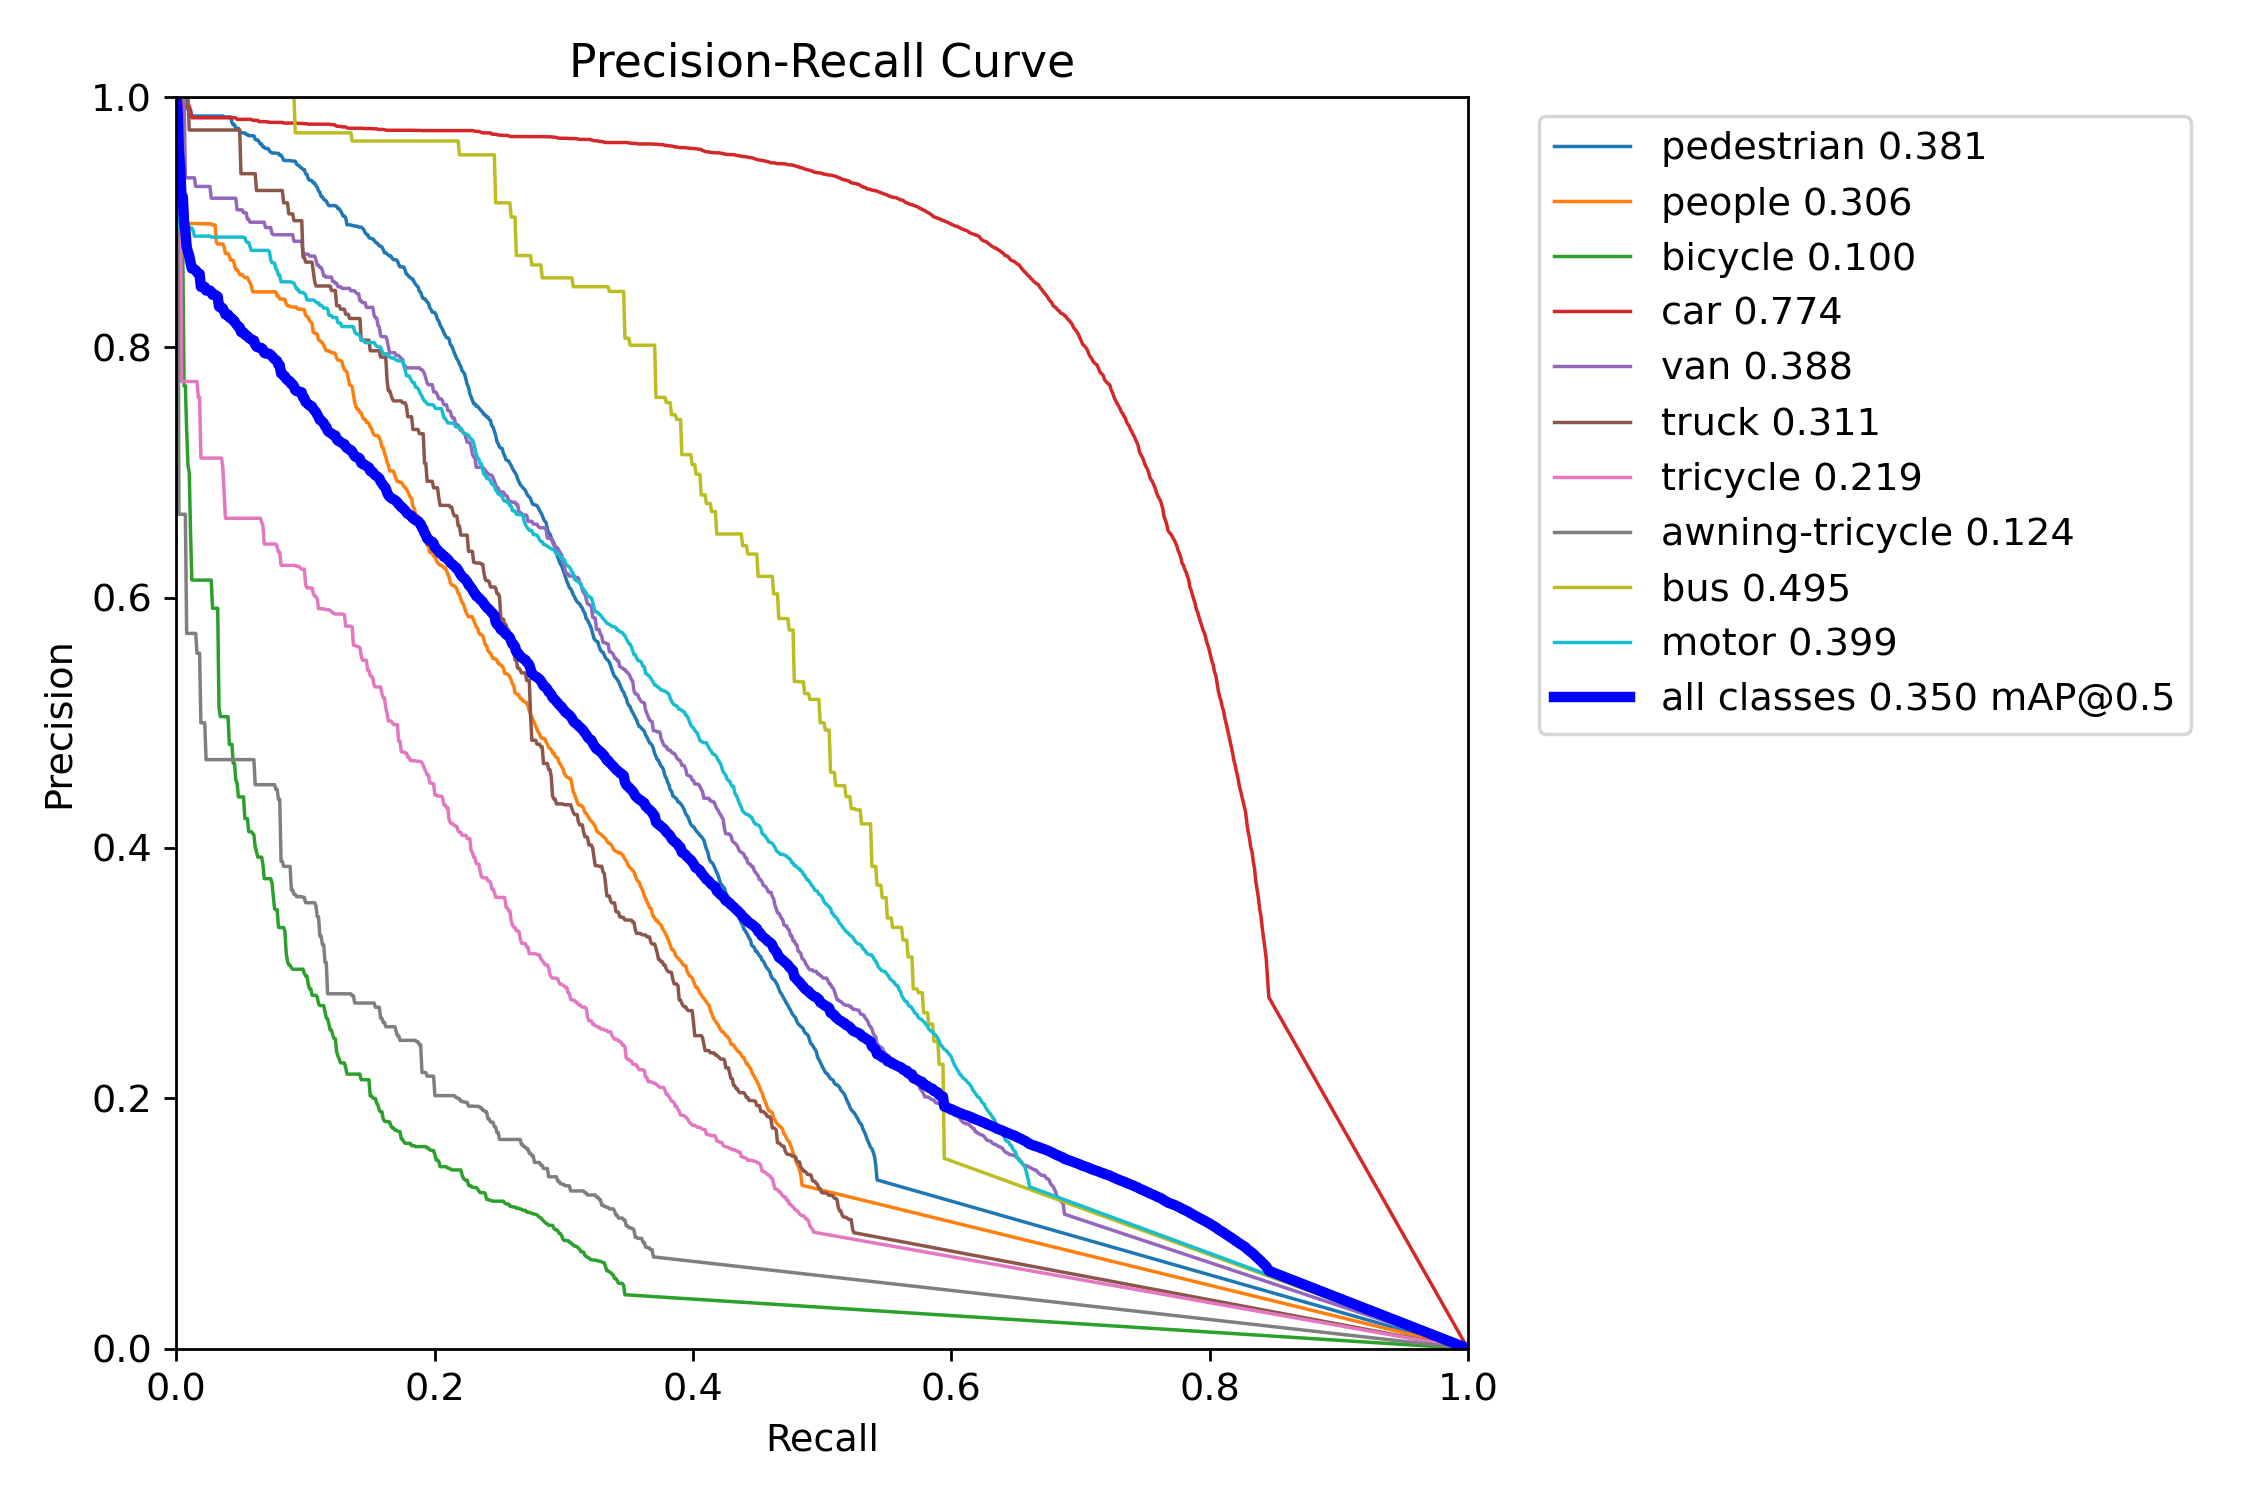

In [ ]:
display(Image(f"{BASE}/BoxPR_curve.png"))

### 5. PR Curve (Precision Recall Curve)

The PR curve plots precision against recall at varying confidence thresholds for each class, with the area under each curve representing the per-class average precision.

**Car** has the strongest PR curve, maintaining high precision across a wide range of recall values.
This is consistent with car being the most represented class in the dataset and the model's strongest performer.

**Motor and Bus** show decent performance compared to the weaker classes, with precision staying fairly consistent at lower recall thresholds before starting to drop. These classes appear often enough in the dataset that the model was able to pick up on their features reasonably well.

**Pedestrian and People** both show curves that start dropping in precision earlier than car and motor. This is likely because pedestrian and people look very similar to each other, especially in drone footage where objects appear small. As the model tries to detect more instances of each class, it starts confusing the two with each other, which causes precision to fall faster.

**Bicycle, Tricycle, and Awning-Tricycle** have the weakest curves, dropping steeply even at low recall values.
These are small, infrequent objects that the model struggles to detect reliably. Even when the confidence threshold is lowered to try to catch more of these objects, the model ends up making a lot of wrong detections, meaning precision drops quickly.

The overall **mAP@50 of 0.3494** is the average across all 10 classes and is pulled down significantly by the weaker classes.
A key takeaway is that model performance is uneven across classes. Improving detection for the smaller and less frequent objects would have the biggest impact on overall mAP.

### **Discussion Summary**

### 6. Overfitting Analysis

There is some mild overfitting present, but it is not severe. Evidence:
- The final training loss (1.3864) is slightly lower than the validation loss (1.4111), which is the classic signature of overfitting: the model performs better on data it has seen than on data that was left out.
- However, the gap (~0.025) is very small and the two curves track each other closely throughout training, meaning the model generalizes reasonably well.

**Possible Causes of overfitting in this experiment:**
- **Dataset size**: When the dataset is small or has underrepresented classes, the model can begin to memorize training samples rather than learning generalizable features. YOLOv11n, while a lightweight model, still has enough capacity to overfit when data diversity is limited.
- **Model capacity vs. data**: Even though YOLOv11n is the nano variant (the smallest in the YOLOv11 family), it still contains millions of parameters. When the number of trainable parameters is large relative to the number of training samples, the model has more freedom to fit noise or dataset-specific patterns.

### 7. Underfitting Analysis

The model does **not exhibit underfitting**. Underfitting would be characterized by high training loss that fails to decrease and mAP scores that do not improve throughout training.

In contrast, this model achieved a training box loss of 1.3864 and mAP@50 of 0.3494, showing that it successfully learned to detect objects across all 10 classes.
The loss curves show clear, sustained descent rather than a flat or barely improving curve.

The mAP@50 of 0.35 and recall of 0.35 reflect a performance ceiling imposed by dataset size and model capacity rather than a failure to learn.
The model learned effectively within its constraints, but further improvement would require more training data or a larger model variant.

### 8. Causes: Dataset Size and Model Capacity

**Dataset Size:**

The size of the training dataset plays a big role in how well the model can learn and generalize. When the dataset is small, the model has fewer examples to learn from, which increases the chance of overfitting because it may start memorizing the training images instead of learning general features. It also means the model gets less exposure to different object appearances, angles, and lighting conditions, which limits how well it can handle unseen images during validation.

Even with a good model, performance is ultimately limited by what the training data covers. If certain classes or scenarios are underrepresented, the model simply will not learn them well, as seen with the weaker classes in our confusion matrix.

While data augmentation techniques such as flipping, scaling, mosaic, and color jitter are applied by default in Ultralytics YOLO and do help the model see more variation, they are not a full replacement for having more real annotated images. Collecting and labeling more data, especially for the weaker classes, would likely lead to noticeable improvements in both recall and mAP.

**Model Capacity:**

YOLOv11n is the nano variant of the YOLOv11 family, meaning it is the smallest and lightest version designed for speed rather than maximum accuracy. Because of its smaller number of parameters compared to larger variants like YOLOv11s or YOLOv11m, the model has less ability to learn complex patterns, which may explain why it struggles with harder classes like bicycle, tricycle, and awning-tricycle.

On the positive side, a smaller model is less likely to overfit, which is consistent with the very small gap we observed between training and validation loss. However, the trade-off is that the model may not have enough capacity to fully learn all the classes in the dataset, especially when those classes are visually similar or appear less frequently in training. If higher accuracy is needed, switching to a larger model variant could help, though this would also require more training data to avoid overfitting.

In [ ]:
summary = {
    "Model": ["YOLOv11n"],
    "Epochs": [len(df)],
    "mAP@50": [round(final['metrics/mAP50(B)'], 4)],
    "mAP@50-95": [round(final['metrics/mAP50-95(B)'], 4)],
    "Precision": [round(final['metrics/precision(B)'], 4)],
    "Recall": [round(final['metrics/recall(B)'], 4)],
}
pd.DataFrame(summary)

,Model,Epochs,mAP@50,mAP@50-95,Precision,Recall
0,YOLOv11n,179,0.3494,0.2014,0.4472,0.3466


**Summary Table:**

| Observation | What Was Seen | Possible Reason |
|---|---|---|
| Mild overfitting | Validation loss is slightly higher than training loss (gap ~0.025) | The dataset may be too small relative to the number of model parameters |
| Model converged before epoch 179 | Both losses stopped improving significantly and early stopping triggered at epoch 129 | Learning rate scheduling slowed updates and the model had learned most of what the dataset could offer |
| Moderate mAP@50 (~0.35) | The model reached its best performance and could not improve beyond that point | Limited by the size of the dataset and the reduced capacity of the nano model |
| Low recall (0.35) | The model missed a large number of ground truth detections | Some classes likely had too few training samples for the model to detect them reliably |